# Complete Analysis

This notebook combines the full analysis flow: aggregate results, timing, operational impact, representative-run timelines, detector forensics, PCAP views, and extra thesis-friendly summary plots.


In [20]:
from pathlib import Path
import sys
import html
import math
import csv
import shutil
import subprocess

import matplotlib.pyplot as plt
import numpy as np


def _find_repo_root(start: Path) -> Path:
    probe = start.resolve()
    for candidate in [probe, *probe.parents]:
        if (candidate / "Makefile").exists() and (candidate / "python" / "reporting").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory")

repo_root = _find_repo_root(Path.cwd())
python_root = str((repo_root / "python").resolve())
if python_root not in sys.path:
    sys.path.insert(0, python_root)

from reporting.dataset import build_rows
from reporting.common import representative_probe_series, representative_row, rows_for_scenario, run_dir_for_row, seconds_between
from metrics.run_artifacts import load_json, load_jsonl, parse_traffic_windows
from metrics.model import ATTACK_TYPE_LABELS, ATTACK_TYPE_ORDER
from scenarios.definitions import MAIN_SCENARIOS, SUPPLEMENTARY_SCENARIOS, SCENARIO_ATTACK_TYPES, SCENARIO_LABELS

TOOL_ORDER = ["detector", "zeek", "suricata"]
TOOL_LABELS = {"detector": "Detector", "zeek": "Zeek", "suricata": "Suricata"}
TOOL_COLORS = {"detector": "#1d4ed8", "zeek": "#d97706", "suricata": "#0f766e"}
SCENARIO_COLORS = {
    "baseline": "#94a3b8",
    "arp-poison-no-forward": "#ef4444",
    "arp-mitm-forward": "#f97316",
    "arp-mitm-dns": "#2563eb",
    "mitigation-recovery": "#14b8a6",
    "intermittent-arp-mitm-dns": "#7c3aed",
    "noisy-benign-baseline": "#64748b",
    "reduced-observability": "#db2777",
}
TARGET = (repo_root / "results").resolve()

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#fffdf8",
        "axes.edgecolor": "#d6d3d1",
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": "#d6d3d1",
        "grid.alpha": 0.30,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.titlesize": 14,
        "legend.frameon": False,
        "font.family": "DejaVu Serif",
        "figure.max_open_warning": 0,
    }
)


def load_rows(profile="all"):
    return build_rows(TARGET, include_warmups=False, use_cache=True, profile=profile)


def scenario_order(rows):
    ordered = [*MAIN_SCENARIOS, *SUPPLEMENTARY_SCENARIOS]
    return [scenario for scenario in ordered if any(row["scenario"] == scenario for row in rows)]


def attack_scenarios(rows):
    return [scenario for scenario in scenario_order(rows) if SCENARIO_ATTACK_TYPES.get(scenario)]


def tool_alert_field(tool):
    return "detector_alerts_native" if tool == "detector" else f"{tool}_alerts"


def mean_or_none(values):
    clean = [float(value) for value in values if value is not None]
    if not clean:
        return None
    return sum(clean) / len(clean)


def display_records(records, columns=None, limit=20):
    if not records:
        print("No rows to display.")
        return
    visible = list(records[:limit])
    columns = list(columns or visible[0].keys())
    header = "".join(f"<th>{html.escape(column)}</th>" for column in columns)
    body = []
    for record in visible:
        body.append("<tr>" + "".join(f"<td>{html.escape(str(record.get(column, '')))}</td>" for column in columns) + "</tr>")
    table_html = f"<table style='border-collapse:collapse;font-size:13px'><thead><tr>{header}</tr></thead><tbody>{''.join(body)}</tbody></table>"
    try:
        from IPython.display import HTML, display
        display(HTML(table_html))
    except Exception:
        for record in visible:
            print(record)


## Results Overview


In [21]:
rows_all = load_rows("all")
rows_main = load_rows("main")
rows_supp = load_rows("supplementary")

print(f"Target: {TARGET}")
display_records([
    {"profile": "all", "rows": len(rows_all)},
    {"profile": "main", "rows": len(rows_main)},
    {"profile": "supplementary", "rows": len(rows_supp)},
], limit=10)


Target: /home/lutyk/Desktop/mad-mitm-in-lan/results


profile,rows
all,65
main,50
supplementary,15


## Scenario summary table

    Start here before looking at the figures. It gives one compact row per scenario with run count, detection rates, and a few operational averages.

In [22]:
summary = []
for scenario in scenario_order(rows_all):
    scenario_rows = rows_for_scenario(rows_all, scenario)
    summary.append({
        "scenario": SCENARIO_LABELS[scenario],
        "runs": len(scenario_rows),
        "detector_rate_pct": mean_or_none([100.0 if row.get("detector_detected") else 0.0 for row in scenario_rows]),
        "zeek_rate_pct": mean_or_none([100.0 if row.get("zeek_detected") else 0.0 for row in scenario_rows]),
        "suricata_rate_pct": mean_or_none([100.0 if row.get("suricata_detected") else 0.0 for row in scenario_rows]),
        "ping_ms": mean_or_none([row.get("ping_gateway_avg_ms") for row in scenario_rows]),
        "curl_s": mean_or_none([row.get("curl_total_s") for row in scenario_rows]),
    })
display_records(summary, limit=20)


scenario,runs,detector_rate_pct,zeek_rate_pct,suricata_rate_pct,ping_ms,curl_s
baseline,10,0.0,0.0,0.0,0.7936804878048781,0.08947594390243903
arp-poison-no-forward,10,100.0,100.0,0.0,0.7462666666666667,1.9870758936507937
arp-mitm-forward,10,100.0,100.0,100.0,1.2695060606060606,0.6663809382352941
arp-mitm-dns,10,100.0,100.0,100.0,1.2564503846153845,1.294262669047619
mitigation-recovery,10,100.0,100.0,100.0,1.1538892857142857,1.0245696357142857
intermittent-arp-mitm-dns,5,100.0,100.0,100.0,0.9741463636363636,4.628087826593406
noisy-benign-baseline,5,0.0,0.0,0.0,0.6868048780487805,0.08590825365853658
reduced-observability,5,100.0,100.0,100.0,1.05199,1.0196883047619048


## Detection rate heatmap

    Darker cells mean the tool usually emitted a relevant alert for that scenario.

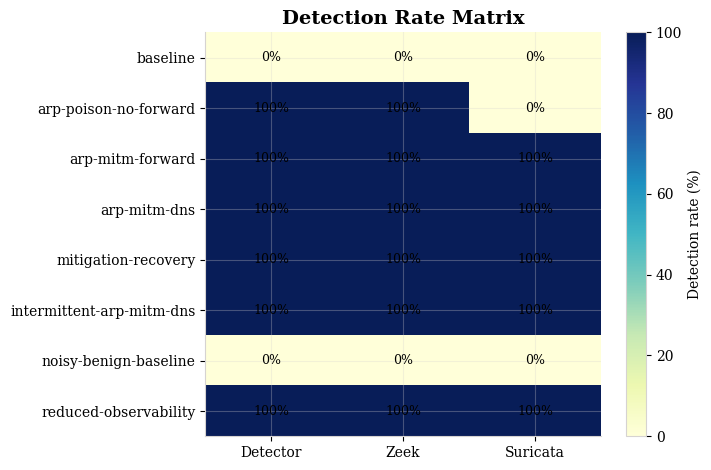

In [23]:
scenarios = scenario_order(rows_all)
matrix = []
for scenario in scenarios:
    scenario_rows = rows_for_scenario(rows_all, scenario)
    matrix.append([
        sum(1 for row in scenario_rows if row.get(f"{tool}_detected")) / len(scenario_rows) * 100.0 if scenario_rows else math.nan
        for tool in TOOL_ORDER
    ])
fig, ax = plt.subplots(figsize=(7.2, max(4, len(scenarios) * 0.6)))
image = ax.imshow(matrix, aspect="auto", cmap="YlGnBu", vmin=0, vmax=100)
ax.set_xticks(range(len(TOOL_ORDER)))
ax.set_xticklabels([TOOL_LABELS[tool] for tool in TOOL_ORDER])
ax.set_yticks(range(len(scenarios)))
ax.set_yticklabels([SCENARIO_LABELS[s] for s in scenarios])
ax.set_title("Detection Rate Matrix")
for r, row in enumerate(matrix):
    for c, value in enumerate(row):
        ax.text(c, r, "n/a" if math.isnan(value) else f"{value:.0f}%", ha="center", va="center", fontsize=9)
fig.colorbar(image, ax=ax, label="Detection rate (%)")
fig.tight_layout()


## Detection rate grouped bars

    This answers the same question as the heatmap, but makes tool-to-tool differences easier to compare inside each scenario.

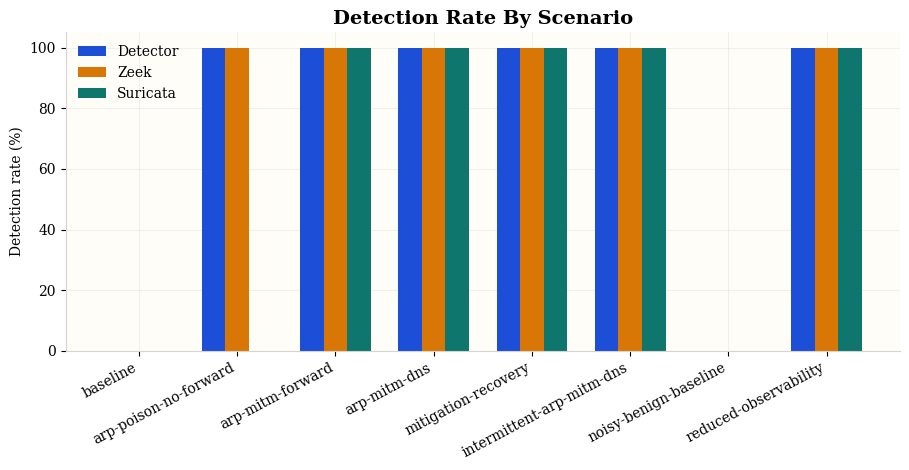

In [24]:
scenarios = scenario_order(rows_all)
labels = [SCENARIO_LABELS[s] for s in scenarios]
positions = list(range(len(labels)))
width = 0.24
fig, ax = plt.subplots(figsize=(max(8, len(labels) * 1.15), 4.8))
for index, tool in enumerate(TOOL_ORDER):
    values = []
    for scenario in scenarios:
        scenario_rows = rows_for_scenario(rows_all, scenario)
        values.append(sum(1 for row in scenario_rows if row.get(f"{tool}_detected")) / len(scenario_rows) * 100.0 if scenario_rows else math.nan)
    offset = (index - 1) * width
    ax.bar([position + offset for position in positions], values, width=width, label=TOOL_LABELS[tool], color=TOOL_COLORS[tool])
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=28, ha="right")
ax.set_ylabel("Detection rate (%)")
ax.set_title("Detection Rate By Scenario")
ax.legend()
fig.tight_layout()


## Mean alert volume by scenario

This older grouped-bar view is useful when you want a quick visual comparison of how noisy each tool is in every scenario.


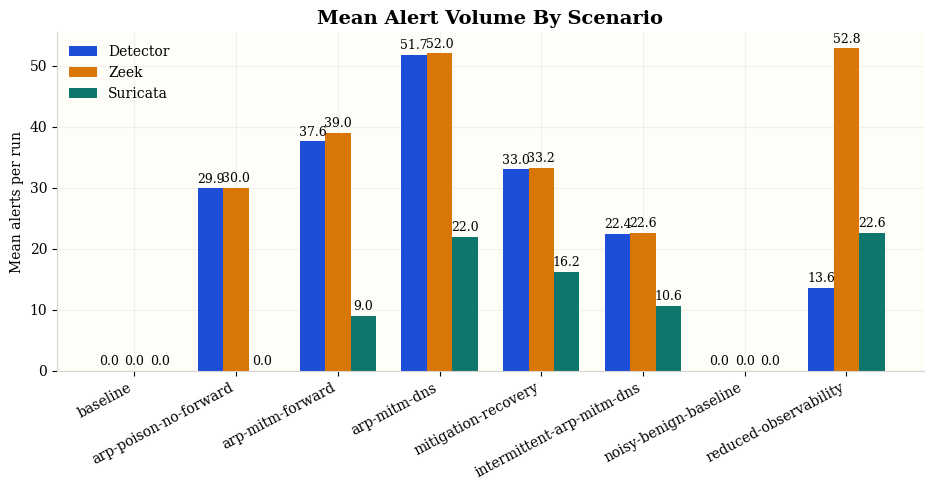

In [25]:
scenarios = scenario_order(rows_all)
labels = scenarios
positions = np.arange(len(labels))
width = 0.25
fig, ax = plt.subplots(figsize=(max(9, len(labels) * 1.18), 5.0))
for index, tool in enumerate(TOOL_ORDER):
    values = [mean_or_none([row.get(tool_alert_field(tool)) for row in rows_for_scenario(rows_all, scenario)]) or 0.0 for scenario in scenarios]
    bars = ax.bar(positions + (index - 1) * width, values, width=width, color=TOOL_COLORS[tool], label=TOOL_LABELS[tool])
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.45, f"{value:.1f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=28, ha="right")
ax.set_ylabel("Mean alerts per run")
ax.set_title("Mean Alert Volume By Scenario")
ax.legend(loc="upper left")
fig.tight_layout()


## Detector semantic alert composition

This stacked view helps explain which semantic signals dominate each scenario instead of looking only at the total alert count.


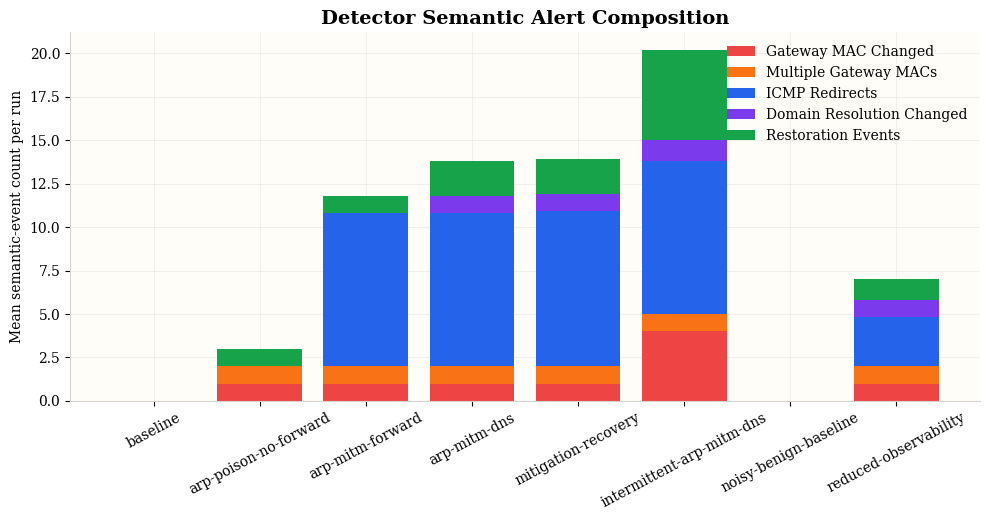

In [26]:
fields = [
    ("gateway_mac_changed", "Gateway MAC Changed", "#ef4444"),
    ("multiple_gateway_macs_seen", "Multiple Gateway MACs", "#f97316"),
    ("icmp_redirects_seen", "ICMP Redirects", "#2563eb"),
    ("domain_resolution_changed", "Domain Resolution Changed", "#7c3aed"),
    ("restoration_events", "Restoration Events", "#16a34a"),
]
scenarios = scenario_order(rows_all)
labels = scenarios
fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.2), 5.3))
bottoms = np.zeros(len(scenarios))
for field, label, color in fields:
    values = np.array([mean_or_none([row.get(field, 0) for row in rows_for_scenario(rows_all, scenario)]) or 0.0 for scenario in scenarios])
    ax.bar(labels, values, bottom=bottoms, label=label, color=color)
    bottoms = bottoms + values
ax.set_ylabel("Mean semantic-event count per run")
ax.set_title("Detector Semantic Alert Composition")
ax.tick_params(axis="x", rotation=28)
ax.legend(loc="upper right")
fig.tight_layout()


## Detection And Timing


In [27]:
def attack_relative_ttd(row, tool):
    ts = row.get("detector_first_alert_at_native") if tool == "detector" else row.get(f"{tool}_first_alert_at")
    return seconds_between(row.get("attack_started_at"), ts)

rows_all = load_rows("all")
rows_attack = [row for row in rows_all if SCENARIO_ATTACK_TYPES.get(str(row["scenario"]))]


## Timing summary table

    Use this to sanity-check the timing interpretation before reading the charts.

In [28]:
summary = []
for scenario in attack_scenarios(rows_attack):
    scenario_rows = rows_for_scenario(rows_attack, scenario)
    record = {"scenario": SCENARIO_LABELS[scenario]}
    for tool in TOOL_ORDER:
        record[f"{tool}_supported_mean"] = mean_or_none([row.get(f"{tool}_ttd_seconds") for row in scenario_rows])
        record[f"{tool}_attack_relative_mean"] = mean_or_none([attack_relative_ttd(row, tool) for row in scenario_rows])
    summary.append(record)
display_records(summary, limit=20)


scenario,detector_supported_mean,detector_attack_relative_mean,zeek_supported_mean,zeek_attack_relative_mean,suricata_supported_mean,suricata_attack_relative_mean
arp-poison-no-forward,0.0008031,41.525831499999995,0.0,41.5250284,None,None
arp-mitm-forward,0.0008246999999999999,41.4987051,0.0,41.4978804,0.0,43.095250500000006
arp-mitm-dns,0.0009981,43.424163,0.0,43.4231649,0.0,45.2243089
mitigation-recovery,0.0010005,43.7115442,0.0,43.7105437,0.0,45.457807100000004
intermittent-arp-mitm-dns,0.0015458,42.9848712,0.0,42.9833254,0.0,44.1141136
reduced-observability,1.9688428000000002,45.4045086,0.0,43.435665799999995,0.0,45.3139096


## Mean attack-relative time-to-detection

This heatmap is the compact thesis-style timing summary: warmer cells mean slower first alert after the attack actually starts.


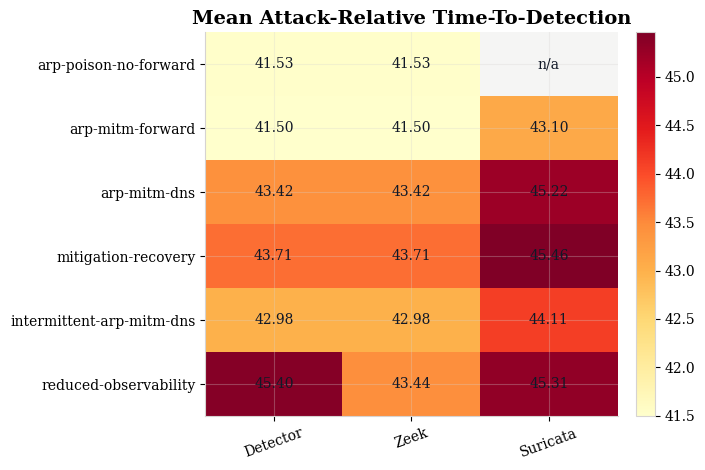

In [29]:
scenarios = attack_scenarios(rows_attack)
labels = scenarios
matrix = []
for scenario in scenarios:
    scenario_rows = rows_for_scenario(rows_attack, scenario)
    matrix.append([mean_or_none([attack_relative_ttd(row, tool) for row in scenario_rows]) for tool in TOOL_ORDER])
matrix = np.array([[np.nan if value is None else float(value) for value in row] for row in matrix], dtype=float)
fig, ax = plt.subplots(figsize=(7.1, 4.8))
cmap = plt.cm.YlOrRd.copy()
cmap.set_bad(color="#f5f5f4")
im = ax.imshow(matrix, cmap=cmap, aspect="auto")
ax.set_xticks(range(len(TOOL_ORDER)))
ax.set_xticklabels([TOOL_LABELS[tool] for tool in TOOL_ORDER], rotation=20)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_title("Mean Attack-Relative Time-To-Detection")
for row_idx in range(matrix.shape[0]):
    for col_idx in range(matrix.shape[1]):
        value = matrix[row_idx, col_idx]
        text = "n/a" if np.isnan(value) else f"{value:.2f}"
        ax.text(col_idx, row_idx, text, ha="center", va="center", color="#111827", fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.048, pad=0.04)
fig.tight_layout()


## Attack-relative detection-time distributions

These panels show the full run-to-run spread. The dots make it easier to see when the box alone hides individual runs.


/tmp/ipykernel_1528497/1448194184.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(safe_series, labels=labels, patch_artist=True, showfliers=False, showmeans=True, meanprops={"marker": "+", "markeredgecolor": point_colors[tool], "markersize": 10})
/tmp/ipykernel_1528497/1448194184.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(safe_series, labels=labels, patch_artist=True, showfliers=False, showmeans=True, meanprops={"marker": "+", "markeredgecolor": point_colors[tool], "markersize": 10})
/tmp/ipykernel_1528497/1448194184.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  

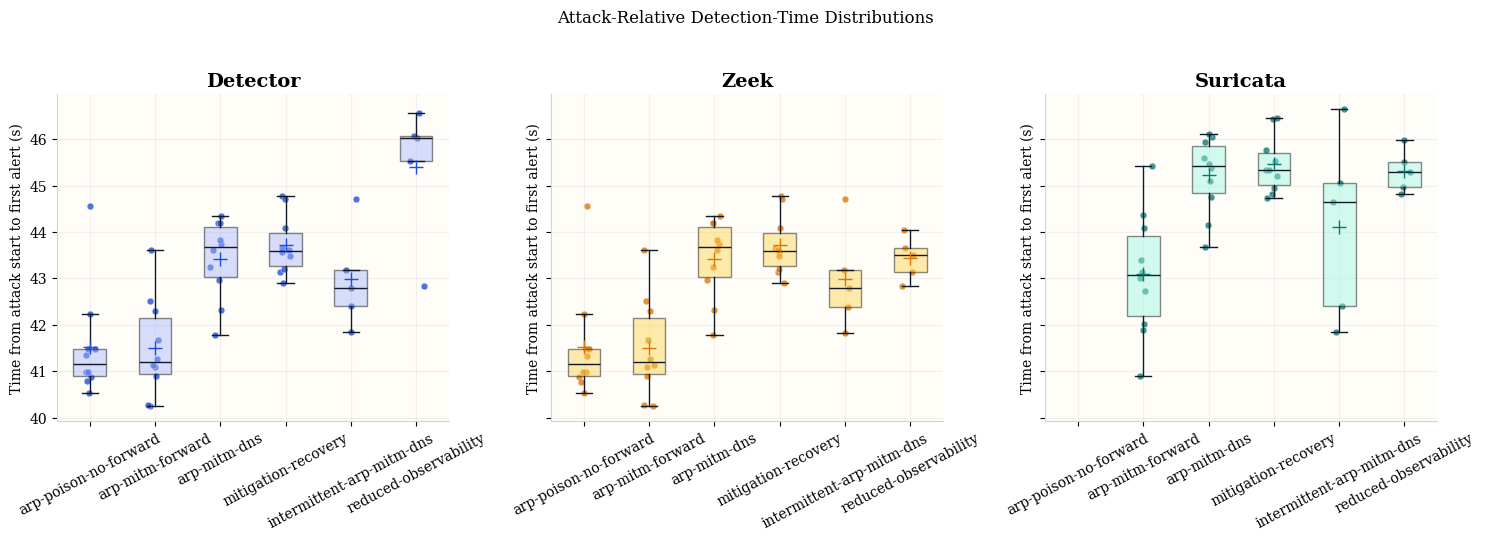

In [30]:
scenarios = attack_scenarios(rows_attack)
labels = scenarios
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), sharey=True)
rng = np.random.default_rng(7)
fill_colors = {"detector": "#a5b4fc", "zeek": "#fcd34d", "suricata": "#99f6e4"}
point_colors = {"detector": "#1d4ed8", "zeek": "#d97706", "suricata": "#0f766e"}
for ax, tool in zip(axes, TOOL_ORDER):
    series = []
    for scenario in scenarios:
        values = [float(attack_relative_ttd(row, tool)) for row in rows_for_scenario(rows_attack, scenario) if attack_relative_ttd(row, tool) is not None]
        series.append(values)
    safe_series = [values if values else [np.nan] for values in series]
    box = ax.boxplot(safe_series, labels=labels, patch_artist=True, showfliers=False, showmeans=True, meanprops={"marker": "+", "markeredgecolor": point_colors[tool], "markersize": 10})
    for patch in box["boxes"]:
        patch.set_facecolor(fill_colors[tool])
        patch.set_alpha(0.45)
    for median in box["medians"]:
        median.set_color("#111827")
    for whisker in box["whiskers"]:
        whisker.set_color("#111827")
    for cap in box["caps"]:
        cap.set_color("#111827")
    for idx, values in enumerate(series, start=1):
        if not values:
            continue
        jitter = rng.normal(idx, 0.06, len(values))
        ax.scatter(jitter, values, s=24, color=point_colors[tool], alpha=0.78, edgecolors="white", linewidths=0.35)
    ax.set_title(TOOL_LABELS[tool])
    ax.set_ylabel("Time from attack start to first alert (s)")
    ax.tick_params(axis="x", rotation=28)
fig.suptitle("Attack-Relative Detection-Time Distributions", y=1.03)
fig.tight_layout()


## ECDF of attack-relative timing

    Steeper, more left-shifted curves mean the tool usually reacts earlier and more consistently.

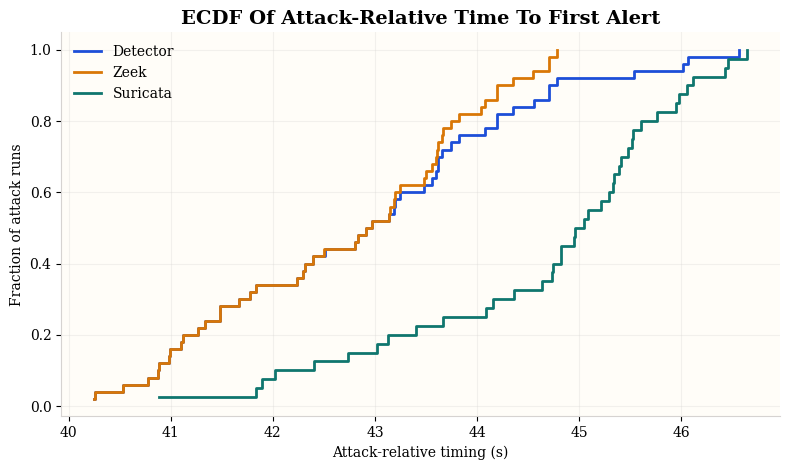

In [31]:
fig, ax = plt.subplots(figsize=(8, 4.8))
for tool in TOOL_ORDER:
    values = sorted(float(attack_relative_ttd(row, tool)) for row in rows_attack if attack_relative_ttd(row, tool) is not None)
    if not values:
        continue
    xs = values
    ys = [(i + 1) / len(values) for i in range(len(values))]
    ax.step(xs, ys, where="post", linewidth=2, color=TOOL_COLORS[tool], label=TOOL_LABELS[tool])
ax.set_xlabel("Attack-relative timing (s)")
ax.set_ylabel("Fraction of attack runs")
ax.set_title("ECDF Of Attack-Relative Time To First Alert")
ax.legend()
fig.tight_layout()


## Which tool alerts first most often?

    This compresses the timing story into a simple race: who wins the first-alert contest most often?

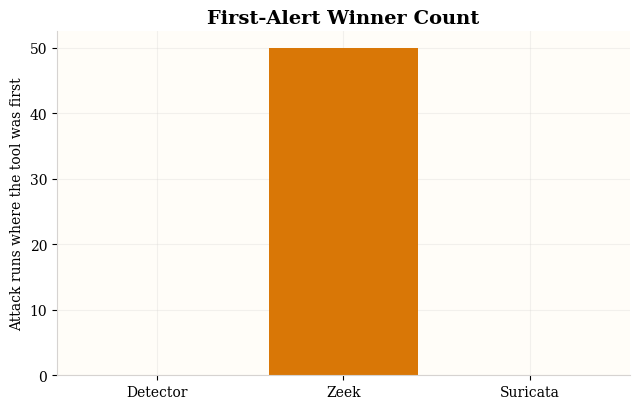

In [32]:
counts = {tool: 0 for tool in TOOL_ORDER}
for row in rows_attack:
    options = []
    for tool in TOOL_ORDER:
        value = attack_relative_ttd(row, tool)
        if value is not None:
            options.append((value, tool))
    if options:
        counts[min(options)[1]] += 1
fig, ax = plt.subplots(figsize=(6.5, 4.2))
labels = [TOOL_LABELS[tool] for tool in TOOL_ORDER]
values = [counts[tool] for tool in TOOL_ORDER]
ax.bar(labels, values, color=[TOOL_COLORS[tool] for tool in TOOL_ORDER])
ax.set_ylabel("Attack runs where the tool was first")
ax.set_title("First-Alert Winner Count")
fig.tight_layout()


## Recovery timing

    This only uses runs where recovery is modeled and measured.

/tmp/ipykernel_1528497/512502466.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values], labels=["mitigation-recovery"], patch_artist=True, showfliers=False)


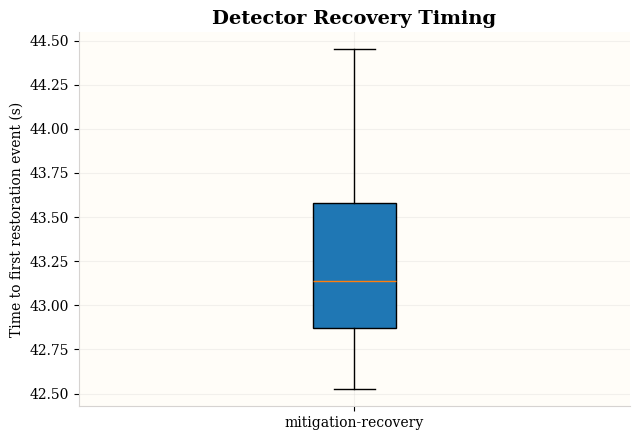

In [33]:
values = [float(row["detector_recovery_seconds"]) for row in rows_attack if row.get("detector_recovery_seconds") is not None]
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.boxplot([values], labels=["mitigation-recovery"], patch_artist=True, showfliers=False)
ax.set_ylabel("Time to first restoration event (s)")
ax.set_title("Detector Recovery Timing")
fig.tight_layout()


## Operational Impact


In [34]:
rows_all = load_rows("all")
baseline_rows = rows_for_scenario(rows_all, "baseline")
baseline_ping = mean_or_none([row.get("ping_gateway_avg_ms") for row in baseline_rows])
baseline_curl = mean_or_none([row.get("curl_total_s") for row in baseline_rows])
baseline_iperf = mean_or_none([row.get("iperf_mbps") for row in baseline_rows])


## Operational summary table

    This gives one compact row per scenario with the main victim-side metrics and their change relative to the clean baseline.

In [35]:
summary = []
for scenario in scenario_order(rows_all):
    scenario_rows = rows_for_scenario(rows_all, scenario)
    ping = mean_or_none([row.get("ping_gateway_avg_ms") for row in scenario_rows])
    curl = mean_or_none([row.get("curl_total_s") for row in scenario_rows])
    iperf = mean_or_none([row.get("iperf_mbps") for row in scenario_rows])
    summary.append({
        "scenario": SCENARIO_LABELS[scenario],
        "ping_ms": ping,
        "curl_s": curl,
        "iperf_mbps": iperf,
        "ping_vs_baseline_pct": ((ping - baseline_ping) / baseline_ping * 100.0) if ping is not None and baseline_ping else None,
        "curl_vs_baseline_pct": ((curl - baseline_curl) / baseline_curl * 100.0) if curl is not None and baseline_curl else None,
        "iperf_vs_baseline_pct": ((iperf - baseline_iperf) / baseline_iperf * 100.0) if iperf is not None and baseline_iperf else None,
    })
display_records(summary, limit=20)


scenario,ping_ms,curl_s,iperf_mbps,ping_vs_baseline_pct,curl_vs_baseline_pct,iperf_vs_baseline_pct
baseline,0.7936804878048781,0.08947594390243903,7223.7662007500185,0.0,0.0,0.0
arp-poison-no-forward,0.7462666666666667,1.9870758936507937,None,-5.973917951460056,2120.7934412152404,None
arp-mitm-forward,1.2695060606060606,0.6663809382352941,7463.980565592935,59.95177909906758,644.759886480649,3.325334156273992
arp-mitm-dns,1.2564503846153845,1.294262669047619,5407.49712265991,58.30682546958062,1346.4923336923175,-25.142965976688608
mitigation-recovery,1.1538892857142857,1.0245696357142857,4314.837750800645,45.38461048798808,1045.0783205276216,-40.26886210197873
intermittent-arp-mitm-dns,0.9741463636363636,4.628087826593406,570.4235299057002,22.73784962644213,5072.4381154779285,-92.10351617074103
noisy-benign-baseline,0.6868048780487805,0.08590825365853658,5820.186759531202,-13.465823010426877,-3.9873178066637873,-19.430023096166753
reduced-observability,1.05199,1.0196883047619048,5087.912993825356,32.54578084810192,1039.6228531254521,-29.567031207390183


## Victim-side operational metrics

This older view mixes boxplots with individual points, which makes the outliers easier to explain when you are talking through runs one by one.


/tmp/ipykernel_1528497/3962834132.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(safe_series, labels=labels, patch_artist=True, showfliers=False, showmeans=True, meanprops={"marker": "+", "markeredgecolor": color, "markersize": 10})
/tmp/ipykernel_1528497/3962834132.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(safe_series, labels=labels, patch_artist=True, showfliers=False, showmeans=True, meanprops={"marker": "+", "markeredgecolor": color, "markersize": 10})
/tmp/ipykernel_1528497/3962834132.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(safe_seri

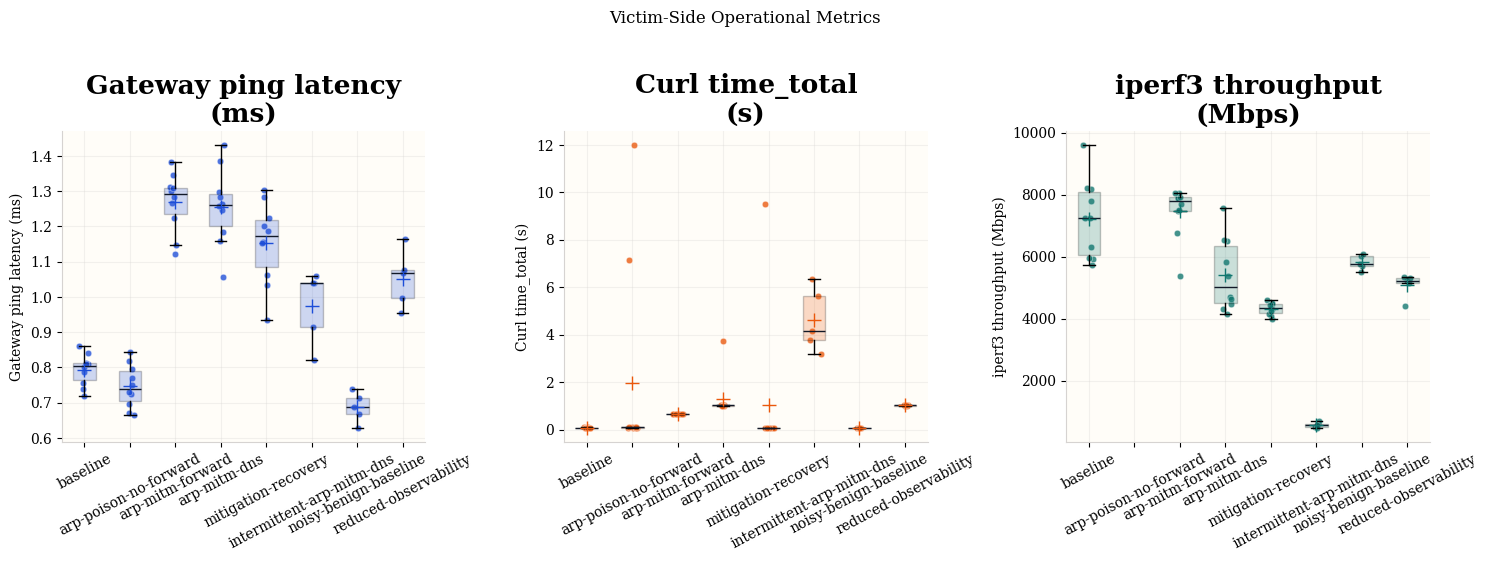

In [36]:
scenarios = scenario_order(rows_all)
labels = scenarios
specs = [
    ("ping_gateway_avg_ms", "Gateway ping latency\n(ms)", "Gateway ping latency (ms)", "#1d4ed8"),
    ("curl_total_s", "Curl time_total\n(s)", "Curl time_total (s)", "#ea580c"),
    ("iperf_mbps", "iperf3 throughput\n(Mbps)", "iperf3 throughput (Mbps)", "#0f766e"),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 5.4))
rng = np.random.default_rng(11)
for ax, (field, title, ylabel, color) in zip(axes, specs):
    series = [[float(row[field]) for row in rows_for_scenario(rows_all, scenario) if row.get(field) is not None] for scenario in scenarios]
    safe_series = [values if values else [np.nan] for values in series]
    box = ax.boxplot(safe_series, labels=labels, patch_artist=True, showfliers=False, showmeans=True, meanprops={"marker": "+", "markeredgecolor": color, "markersize": 10})
    for patch in box["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.22)
    for median in box["medians"]:
        median.set_color("#111827")
    for idx, values in enumerate(series, start=1):
        if not values:
            continue
        jitter = rng.normal(idx, 0.06, len(values))
        ax.scatter(jitter, values, s=22, color=color, alpha=0.78, edgecolors="white", linewidths=0.35)
    ax.set_title(title, fontsize=19)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=28)
fig.suptitle("Victim-Side Operational Metrics", y=1.03)
fig.tight_layout()


## Baseline-relative overhead

    This is the easiest plot to cite in text when you want to say how much worse a scenario is than normal.

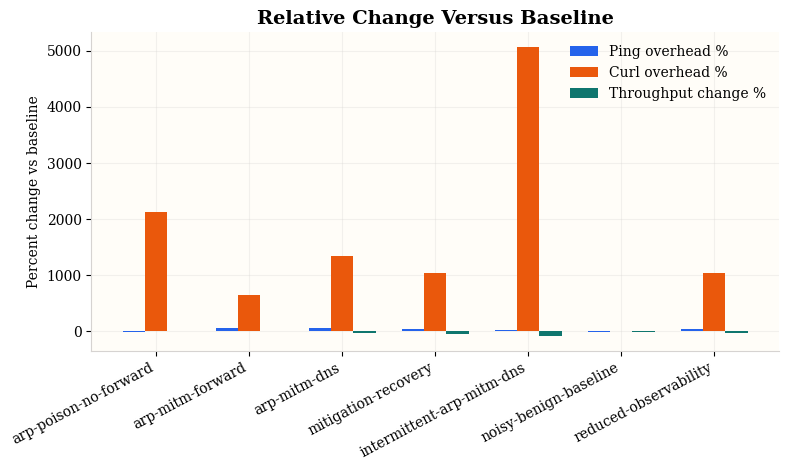

In [37]:
scenarios = [scenario for scenario in scenario_order(rows_all) if scenario != "baseline"]
labels = [SCENARIO_LABELS[s] for s in scenarios]
positions = list(range(len(labels)))
width = 0.24
ping_over = []
curl_over = []
iperf_change = []
for scenario in scenarios:
    scenario_rows = rows_for_scenario(rows_all, scenario)
    ping = mean_or_none([row.get("ping_gateway_avg_ms") for row in scenario_rows])
    curl = mean_or_none([row.get("curl_total_s") for row in scenario_rows])
    iperf = mean_or_none([row.get("iperf_mbps") for row in scenario_rows])
    ping_over.append(((ping - baseline_ping) / baseline_ping * 100.0) if ping is not None and baseline_ping else 0.0)
    curl_over.append(((curl - baseline_curl) / baseline_curl * 100.0) if curl is not None and baseline_curl else 0.0)
    iperf_change.append(((iperf - baseline_iperf) / baseline_iperf * 100.0) if iperf is not None and baseline_iperf else 0.0)
fig, ax = plt.subplots(figsize=(max(8, len(labels) * 1.15), 4.8))
ax.bar([p - width for p in positions], ping_over, width=width, color="#2563eb", label="Ping overhead %")
ax.bar(positions, curl_over, width=width, color="#ea580c", label="Curl overhead %")
ax.bar([p + width for p in positions], iperf_change, width=width, color="#0f766e", label="Throughput change %")
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=28, ha="right")
ax.set_ylabel("Percent change vs baseline")
ax.set_title("Relative Change Versus Baseline")
ax.legend()
fig.tight_layout()


## Distribution shape of operational metrics

The violin version keeps the same story but emphasizes how concentrated or spread out each scenario is for every metric.


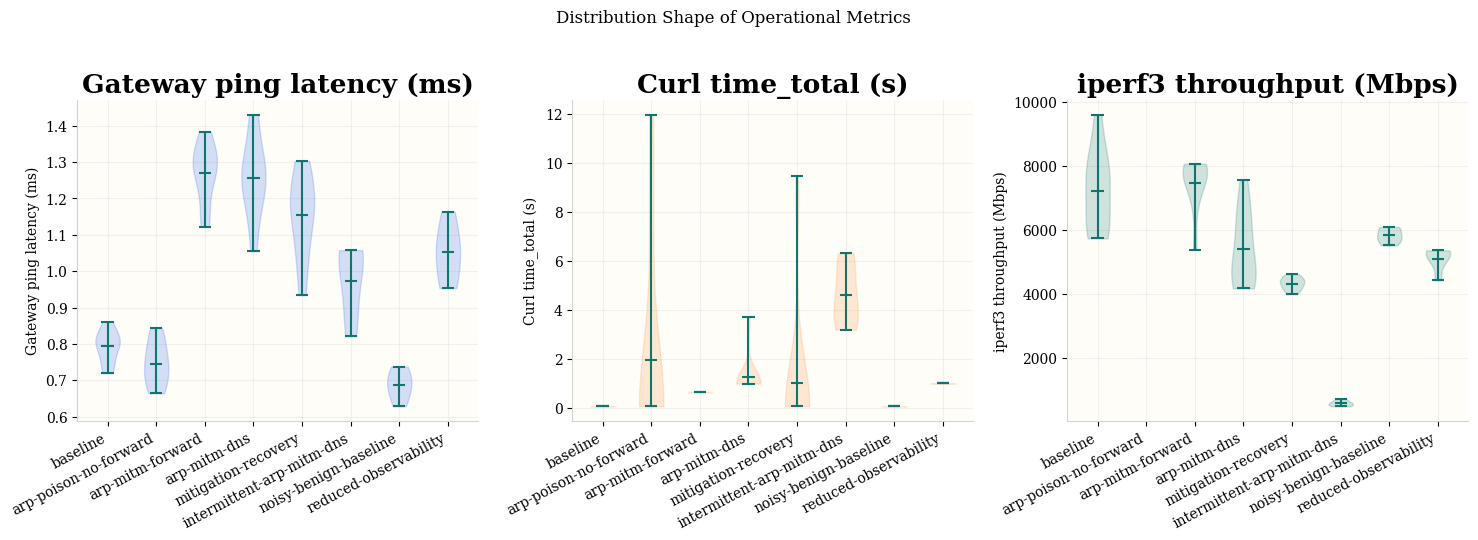

In [39]:
scenarios = scenario_order(rows_all)
labels = scenarios
specs = [
    ("ping_gateway_avg_ms", "Gateway ping latency (ms)", "#2563eb"),
    ("curl_total_s", "Curl time_total (s)", "#fb923c"),
    ("iperf_mbps", "iperf3 throughput (Mbps)", "#0f766e"),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
for ax, (field, title, color) in zip(axes, specs):
    data = [[float(row[field]) for row in rows_for_scenario(rows_all, scenario) if row.get(field) is not None] for scenario in scenarios]
    non_empty = [(i + 1, values) for i, values in enumerate(data) if values]
    if non_empty:
        positions = [i for i, _ in non_empty]
        series = [values for _, values in non_empty]
        parts = ax.violinplot(series, positions=positions, showmeans=True, showmedians=False)
        for body in parts["bodies"]:
            body.set_facecolor(color)
            body.set_edgecolor(color)
            body.set_alpha(0.20)
        parts["cmeans"].set_color("#0f766e")
        parts["cbars"].set_color("#0f766e")
        parts["cmins"].set_color("#0f766e")
        parts["cmaxes"].set_color("#0f766e")
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=28, ha="right")
    ax.set_title(title, fontsize=19)
    ax.set_ylabel(title)
fig.suptitle("Distribution Shape of Operational Metrics", y=1.03)
fig.tight_layout()


## Representative Run Deep Dive


In [40]:
def choose_row(rows, run_id=None):
    if run_id is not None:
        for row in rows:
            if str(row["run_id"]) == str(run_id):
                return row
        raise KeyError(f"Run id not found: {run_id}")
    row = representative_row(
        rows,
        ["mitigation-recovery", "arp-mitm-dns", "arp-mitm-forward", "arp-poison-no-forward"],
        lambda item: any(item.get(field) is not None for field in ["detector_first_alert_at_native", "zeek_first_alert_at", "suricata_first_alert_at"]),
    )
    if row is None:
        raise ValueError("Could not choose a representative run")
    return row

def timing_reference_info(row):
    evaluation = load_json(run_dir_for_row(row) / "evaluation.json")
    return {
        "planned_start": seconds_between(row.get("started_at"), row.get("attack_started_at")),
        "planned_stop": seconds_between(row.get("started_at"), row.get("attack_stopped_at")),
        "observed_start": seconds_between(row.get("started_at"), evaluation.get("ground_truth_attack_started_at")),
        "observed_start_ts": evaluation.get("ground_truth_attack_started_at"),
    }

def add_time_context(ax, row):
    info = timing_reference_info(row)
    if info["planned_start"] is not None and info["planned_stop"] is not None and info["planned_stop"] >= info["planned_start"]:
        ax.axvspan(info["planned_start"], info["planned_stop"], color="#e7e5e4", alpha=0.42)
    if info["observed_start"] is not None:
        ax.axvline(info["observed_start"], color="#b91c1c", linewidth=1.5, linestyle="--")
    ax.text(0.01, 0.97, "gray = planned phase, red dashed = first observed attack evidence", transform=ax.transAxes, va="top", fontsize=8)
    return info

def attack_relative_ttd(row, tool):
    ts = row.get("detector_first_alert_at_native") if tool == "detector" else row.get(f"{tool}_first_alert_at")
    return seconds_between(row.get("attack_started_at"), ts)

rows_all = load_rows("all")
RUN_ID = None
row = choose_row(rows_all, RUN_ID)

timing = timing_reference_info(row)
display_records([
    {"field": "run_id", "value": row["run_id"]},
    {"field": "scenario", "value": SCENARIO_LABELS[str(row["scenario"])]},
    {"field": "planned_attack_start", "value": row.get("attack_started_at")},
    {"field": "planned_attack_stop", "value": row.get("attack_stopped_at")},
    {"field": "observed_attack_start", "value": timing["observed_start_ts"]},
    {"field": "planned_start_offset_s", "value": timing["planned_start"]},
    {"field": "observed_start_offset_s", "value": timing["observed_start"]},
], limit=20)

display_records([
    {
        "tool": TOOL_LABELS[tool],
        "first_alert_at": row.get("detector_first_alert_at_native") if tool == "detector" else row.get(f"{tool}_first_alert_at"),
        "supported_ttd_s": row.get(f"{tool}_ttd_seconds"),
        "attack_relative_ttd_s": attack_relative_ttd(row, tool),
        "alerts": row.get(tool_alert_field(tool)),
    }
    for tool in TOOL_ORDER
], limit=10)


field,value
run_id,20260418T224348Z
scenario,mitigation-recovery
planned_attack_start,2026-04-18T22:43:58+00:00
planned_attack_stop,2026-04-18T22:44:33+00:00
observed_attack_start,2026-04-18T22:44:41.140880+00:00
planned_start_offset_s,10.0
observed_start_offset_s,53.14088


tool,first_alert_at,supported_ttd_s,attack_relative_ttd_s,alerts
Detector,2026-04-18T22:44:41.141849+00:00,0.000969,43.141849,27
Zeek,2026-04-18T22:44:41.140880+00:00,0.0,43.14088,28
Suricata,2026-04-18T22:44:42.948919+0000,0.0,44.948919,11


## Attack-type counts

    The simplest run-level comparison of what each tool actually saw.

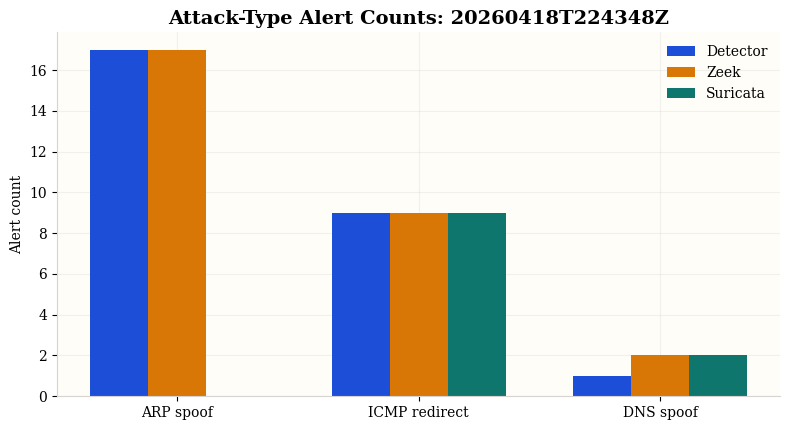

In [41]:
attack_types = [attack_type for attack_type in ATTACK_TYPE_ORDER if attack_type in SCENARIO_ATTACK_TYPES.get(str(row["scenario"]), set())]
labels = [ATTACK_TYPE_LABELS[a] for a in attack_types]
positions = list(range(len(labels)))
width = 0.24
fig, ax = plt.subplots(figsize=(8.0, 4.4))
for index, tool in enumerate(TOOL_ORDER):
    values = [float(row.get(f"{tool}_attack_type_counts", {}).get(attack_type, 0)) for attack_type in attack_types]
    ax.bar([position + (index - 1) * width for position in positions], values, width=width, color=TOOL_COLORS[tool], label=TOOL_LABELS[tool])
ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylabel("Alert count")
ax.set_title(f"Attack-Type Alert Counts: {row['run_id']}")
ax.legend()
fig.tight_layout()


## Timeline

    This is the cleanest view of when each tool reacted relative to observed attack evidence.

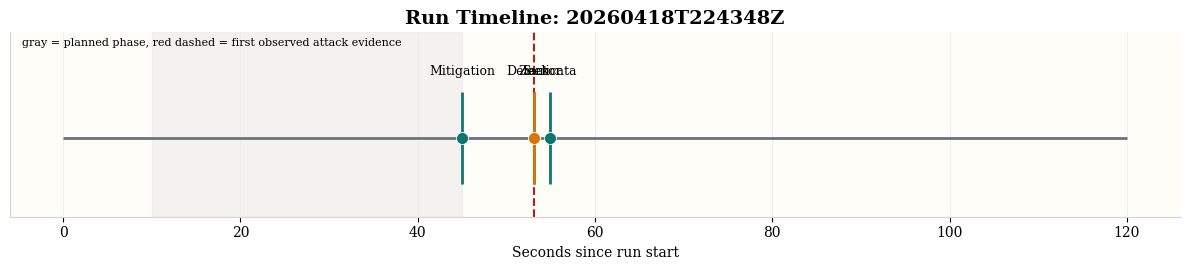

In [42]:
fig, ax = plt.subplots(figsize=(12, 2.8))
duration = float(row.get("duration_seconds") or 0)
ax.hlines(0, 0, duration, color="#6b7280", linewidth=2)
add_time_context(ax, row)
for label, timestamp, color in [
    ("Detector", row.get("detector_first_alert_at_native"), TOOL_COLORS["detector"]),
    ("Zeek", row.get("zeek_first_alert_at"), TOOL_COLORS["zeek"]),
    ("Suricata", row.get("suricata_first_alert_at"), TOOL_COLORS["suricata"]),
    ("Mitigation", row.get("mitigation_started_at"), "#0f766e"),
]:
    offset = seconds_between(row.get("started_at"), timestamp)
    if offset is None:
        continue
    ax.vlines(offset, -0.35, 0.35, color=color, linewidth=2)
    ax.scatter([offset], [0], s=74, color=color, edgecolors="white", linewidths=0.55, zorder=3)
    ax.text(offset, 0.45, label, ha="center", va="bottom", fontsize=9)
ax.set_title(f"Run Timeline: {row['run_id']}")
ax.set_xlabel("Seconds since run start")
ax.set_yticks([])
ax.set_ylim(-0.6, 0.8)
fig.tight_layout()


## Probe trace

    Victim-side latency behavior aligned with the same timing reference.

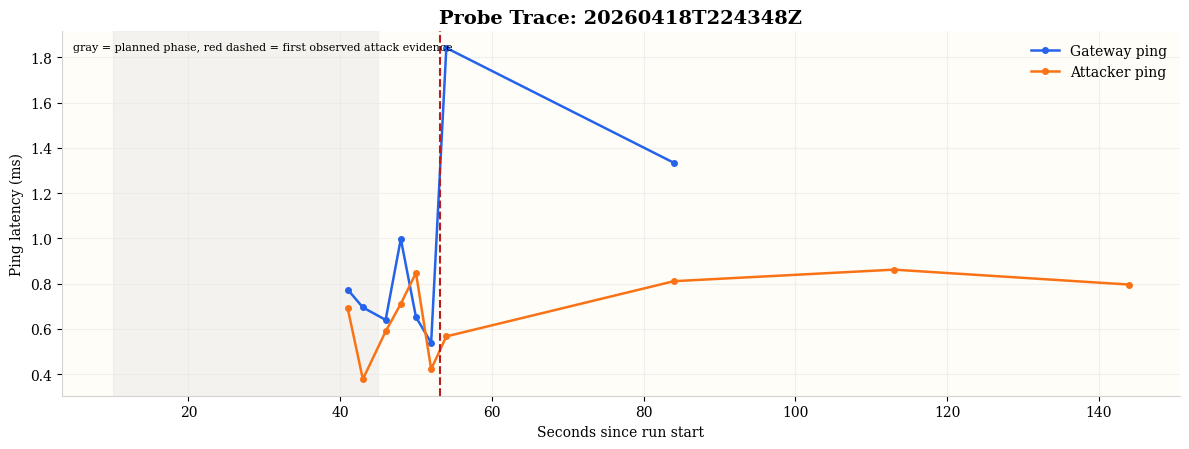

In [43]:
payload = representative_probe_series(row)
if payload is None:
    print("No probe series found for this run.")
else:
    x_values, series = payload
    fig, ax = plt.subplots(figsize=(12, 4.6))
    for name, values in series.items():
        color = "#2563eb" if "Gateway" in name else "#f97316"
        ax.plot(x_values, values, marker="o", linewidth=1.8, markersize=4, label=name, color=color)
    add_time_context(ax, row)
    ax.set_title(f"Probe Trace: {row['run_id']}")
    ax.set_xlabel("Seconds since run start")
    ax.set_ylabel("Ping latency (ms)")
    ax.legend()
    fig.tight_layout()


## Curl timeline

    The application-level view of the same run.

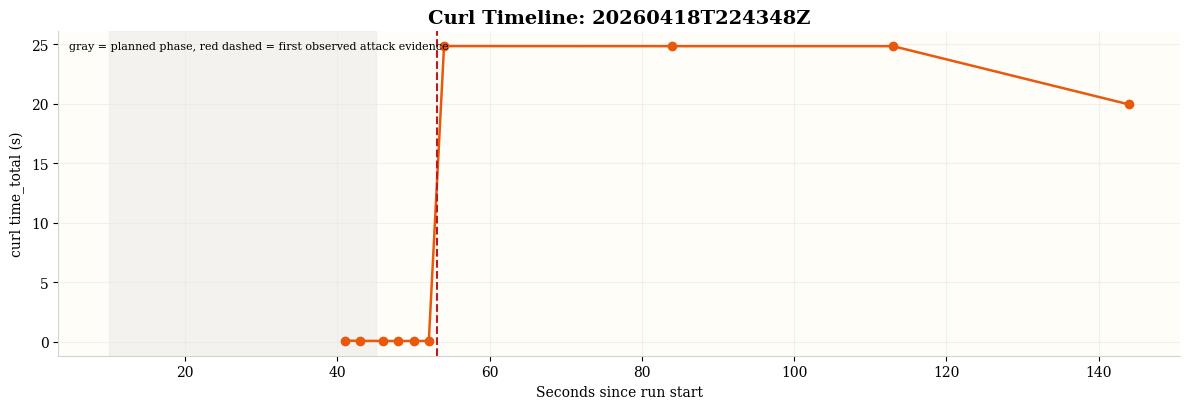

In [44]:
meta = load_json(run_dir_for_row(row) / "run-meta.json")
windows = parse_traffic_windows(run_dir_for_row(row) / "victim" / "traffic-window.txt", gateway_ip=meta.get("gateway_lab_ip"), attacker_ip=meta.get("attacker_ip"))
xs, ys = [], []
for window in windows:
    offset = seconds_between(row.get("started_at"), window.ts)
    if offset is None or window.curl_total_s is None:
        continue
    xs.append(offset)
    ys.append(float(window.curl_total_s))
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(xs, ys, marker="o", linewidth=1.8, color="#ea580c")
add_time_context(ax, row)
ax.set_title(f"Curl Timeline: {row['run_id']}")
ax.set_xlabel("Seconds since run start")
ax.set_ylabel("curl time_total (s)")
fig.tight_layout()


## Detector state flags

    These are easier to interpret than packet counters when explaining what the detector believed about the network.

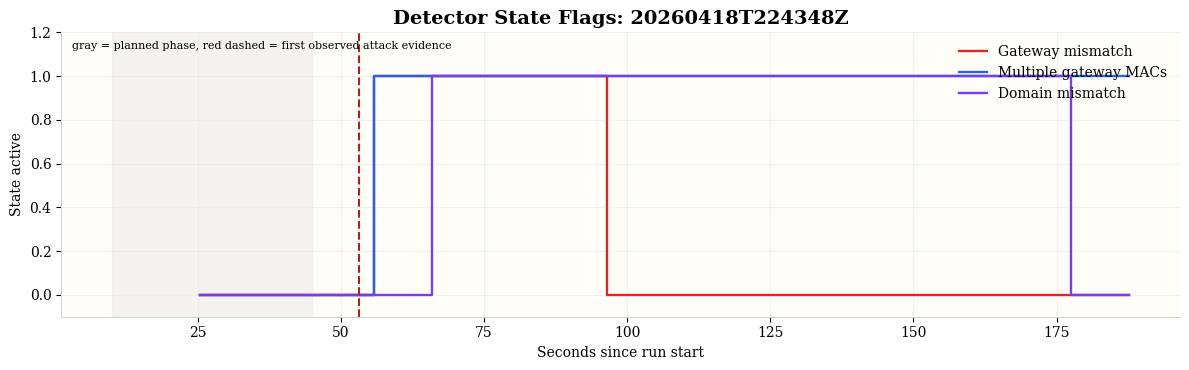

In [45]:
records = [record for record in load_jsonl(run_dir_for_row(row) / "victim" / "detector.delta.jsonl") if record.get("event") == "heartbeat"]
xs, mismatch, multi, domain = [], [], [], []
for record in records:
    offset = seconds_between(row.get("started_at"), record.get("ts"))
    if offset is None:
        continue
    xs.append(offset)
    mismatch.append(1.0 if record.get("gateway_mismatch_active") else 0.0)
    multi.append(1.0 if record.get("multi_gateway_active") else 0.0)
    domain.append(1.0 if any(bool(value) for value in (record.get("domain_mismatch_active") or {}).values()) else 0.0)
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.step(xs, mismatch, where="post", linewidth=1.7, label="Gateway mismatch", color="#dc2626")
ax.step(xs, multi, where="post", linewidth=1.7, label="Multiple gateway MACs", color="#2563eb")
ax.step(xs, domain, where="post", linewidth=1.7, label="Domain mismatch", color="#7c3aed")
add_time_context(ax, row)
ax.set_ylim(-0.1, 1.2)
ax.set_title(f"Detector State Flags: {row['run_id']}")
ax.set_xlabel("Seconds since run start")
ax.set_ylabel("State active")
ax.legend(loc="upper right")
fig.tight_layout()


## Detector event raster

    This shows event ordering and bursts without averaging the run away.

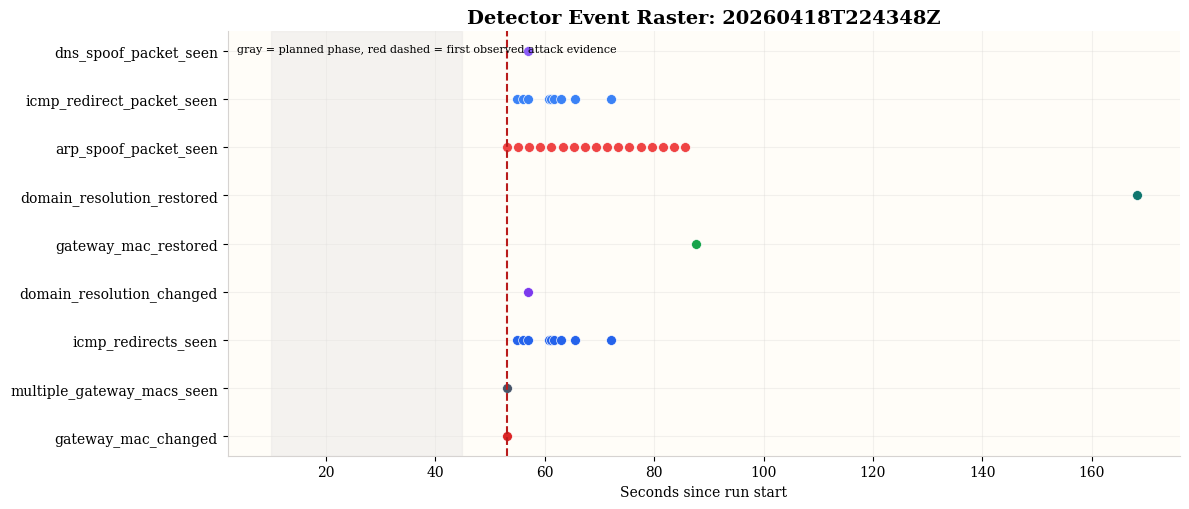

In [46]:
records = load_jsonl(run_dir_for_row(row) / "victim" / "detector.delta.jsonl")
event_names = [
    "gateway_mac_changed",
    "multiple_gateway_macs_seen",
    "icmp_redirects_seen",
    "domain_resolution_changed",
    "gateway_mac_restored",
    "domain_resolution_restored",
    "arp_spoof_packet_seen",
    "icmp_redirect_packet_seen",
    "dns_spoof_packet_seen",
]
fig, ax = plt.subplots(figsize=(12, 5.2))
for idx, event_name in enumerate(event_names):
    offsets = [seconds_between(row.get("started_at"), record.get("ts")) for record in records if record.get("event") == event_name]
    offsets = [offset for offset in offsets if offset is not None]
    if offsets:
        ax.scatter(offsets, [idx] * len(offsets), s=50, color="#475569" if event_name not in ["gateway_mac_changed", "icmp_redirects_seen", "domain_resolution_changed", "gateway_mac_restored", "domain_resolution_restored", "arp_spoof_packet_seen", "icmp_redirect_packet_seen", "dns_spoof_packet_seen"] else {
            "gateway_mac_changed": "#dc2626",
            "icmp_redirects_seen": "#2563eb",
            "domain_resolution_changed": "#7c3aed",
            "gateway_mac_restored": "#16a34a",
            "domain_resolution_restored": "#0f766e",
            "arp_spoof_packet_seen": "#ef4444",
            "icmp_redirect_packet_seen": "#3b82f6",
            "dns_spoof_packet_seen": "#8b5cf6",
        }[event_name], edgecolors="white", linewidths=0.45)
add_time_context(ax, row)
ax.set_title(f"Detector Event Raster: {row['run_id']}")
ax.set_xlabel("Seconds since run start")
ax.set_yticks(range(len(event_names)))
ax.set_yticklabels(event_names)
fig.tight_layout()


## Probe-window domain observations

    This is the concrete victim-visible DNS/application table for the selected run.

In [48]:
meta = load_json(run_dir_for_row(row) / "run-meta.json")
windows = parse_traffic_windows(run_dir_for_row(row) / "victim" / "traffic-window.txt", gateway_ip=meta.get("gateway_lab_ip"), attacker_ip=meta.get("attacker_ip"))
records = []
for window in windows:
    offset = seconds_between(row.get("started_at"), window.ts)
    if offset is None:
        continue
    domains = {name: ", ".join(values[:3]) for name, values in window.domains.items()}
    records.append({
        "seconds": offset,
        "gateway_ping_ms": window.ping_gateway_avg_ms,
        "attacker_ping_ms": window.ping_attacker_avg_ms,
        "curl_total_s": window.curl_total_s,
        "example.com": domains.get("example.com", ""),
        "example.org": domains.get("example.org", ""),
        "iana.org": domains.get("iana.org", ""),
    })
display_records(records, limit=30)


seconds,gateway_ping_ms,attacker_ping_ms,curl_total_s,example.com,example.org,iana.org
41.0,0.774,0.691,0.107535,"172.66.147.243, 104.20.23.154","172.66.157.237, 104.20.26.136",192.0.43.8
43.0,0.695,0.378,0.088345,"104.20.23.154, 172.66.147.243","104.20.26.136, 172.66.157.237",192.0.43.8
46.0,0.64,0.589,0.079666,"172.66.147.243, 104.20.23.154","172.66.157.237, 104.20.26.136",192.0.43.8
48.0,0.998,0.711,0.078667,"104.20.23.154, 172.66.147.243","104.20.26.136, 172.66.157.237",192.0.43.8
50.0,0.652,0.848,0.079061,"172.66.147.243, 104.20.23.154","172.66.157.237, 104.20.26.136",192.0.43.8
52.0,0.539,0.422,0.083016,"104.20.23.154, 172.66.147.243","104.20.26.136, 172.66.157.237",192.0.43.8
54.0,1.842,0.567,24.827825,,,10.20.20.66
84.0,1.334,0.811,24.820044,,,10.20.20.66
113.0,None,0.862,24.820114,,,
144.0,None,0.796,19.931367,,,


## Detector Event Forensics


In [49]:
rows_all = load_rows("all")


## Noisiest detector runs

    This table is the quickest way to see which retained runs produced the richest or noisiest detector evidence.

In [50]:
records = []
for row in rows_all:
    detector_records = load_jsonl(run_dir_for_row(row) / "victim" / "detector.delta.jsonl")
    semantic_total = sum(1 for record in detector_records if record.get("event") in {
        "gateway_mac_changed", "multiple_gateway_macs_seen", "icmp_redirects_seen", "domain_resolution_changed", "gateway_mac_restored", "domain_resolution_restored", "single_gateway_mac_restored"
    })
    packet_total = sum(1 for record in detector_records if record.get("event") in {"arp_spoof_packet_seen", "icmp_redirect_packet_seen", "dns_spoof_packet_seen"})
    records.append({"run_id": row["run_id"], "scenario": SCENARIO_LABELS[str(row["scenario"])], "semantic_total": semantic_total, "packet_total": packet_total})
records = sorted(records, key=lambda item: (item["semantic_total"], item["packet_total"]), reverse=True)
display_records(records, limit=20)


run_id,scenario,semantic_total,packet_total
20260418T192352Z,intermittent-arp-mitm-dns,22,23
20260418T192935Z,intermittent-arp-mitm-dns,20,23
20260418T193227Z,intermittent-arp-mitm-dns,20,23
20260418T193518Z,intermittent-arp-mitm-dns,20,22
20260418T192645Z,intermittent-arp-mitm-dns,19,21
20260418T221130Z,arp-mitm-dns,14,53
20260418T221423Z,arp-mitm-dns,14,53
20260418T222010Z,arp-mitm-dns,14,53
20260418T222557Z,arp-mitm-dns,14,53
20260418T223728Z,arp-mitm-dns,14,53


## Mean semantic-event counts

    This is the detector's victim-side state-change surface, averaged per scenario.

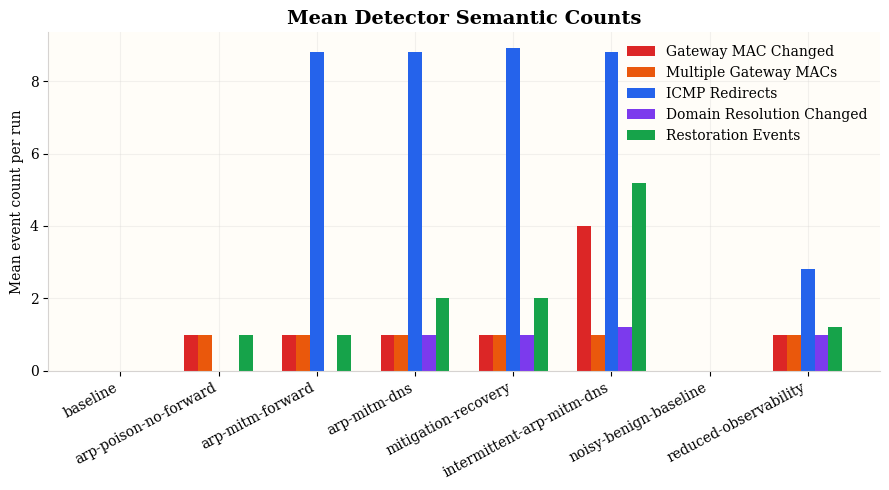

In [51]:
fields = [
    ("gateway_mac_changed", "Gateway MAC Changed", "#dc2626"),
    ("multiple_gateway_macs_seen", "Multiple Gateway MACs", "#ea580c"),
    ("icmp_redirects_seen", "ICMP Redirects", "#2563eb"),
    ("domain_resolution_changed", "Domain Resolution Changed", "#7c3aed"),
    ("restoration_events", "Restoration Events", "#16a34a"),
]
scenarios = scenario_order(rows_all)
labels = [SCENARIO_LABELS[s] for s in scenarios]
positions = list(range(len(labels)))
width = 0.14
fig, ax = plt.subplots(figsize=(max(9, len(labels) * 1.1), 5.0))
for index, (field, label, color) in enumerate(fields):
    values = [mean_or_none([row.get(field, 0) for row in rows_for_scenario(rows_all, scenario)]) or 0.0 for scenario in scenarios]
    ax.bar([position + (index - 2) * width for position in positions], values, width=width, color=color, label=label)
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=28, ha="right")
ax.set_ylabel("Mean event count per run")
ax.set_title("Mean Detector Semantic Counts")
ax.legend(loc="upper right")
fig.tight_layout()


## Mean detector packet-alert counts

    This is the packet-level side of the detector, separated from the semantic events.

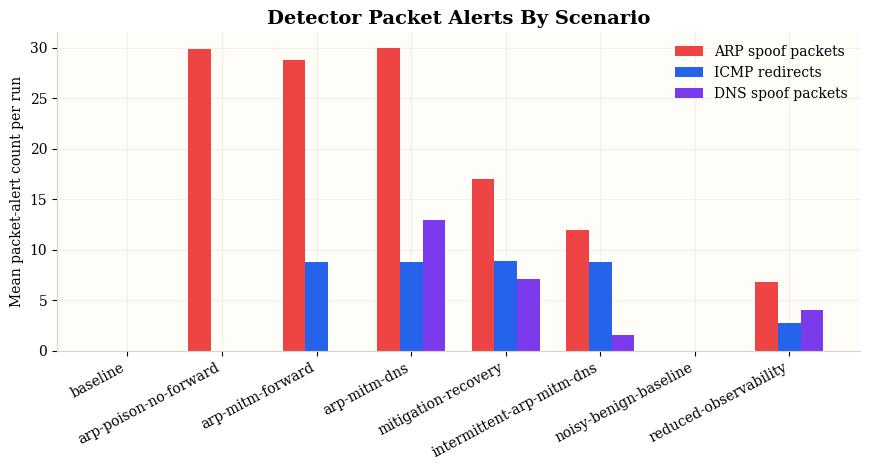

In [52]:
attack_types = [("arp_spoof", "ARP spoof packets", "#ef4444"), ("icmp_redirect", "ICMP redirects", "#2563eb"), ("dns_spoof", "DNS spoof packets", "#7c3aed")]
scenarios = scenario_order(rows_all)
labels = [SCENARIO_LABELS[s] for s in scenarios]
positions = list(range(len(labels)))
width = 0.24
fig, ax = plt.subplots(figsize=(max(8, len(labels) * 1.1), 4.8))
for index, (attack_type, label, color) in enumerate(attack_types):
    values = [mean_or_none([row.get("detector_attack_type_counts", {}).get(attack_type, 0) for row in rows_for_scenario(rows_all, scenario)]) or 0.0 for scenario in scenarios]
    ax.bar([position + (index - 1) * width for position in positions], values, width=width, color=color, label=label)
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=28, ha="right")
ax.set_ylabel("Mean packet-alert count per run")
ax.set_title("Detector Packet Alerts By Scenario")
ax.legend()
fig.tight_layout()


## Share of runs that contain each semantic event

    This is about consistency rather than volume.

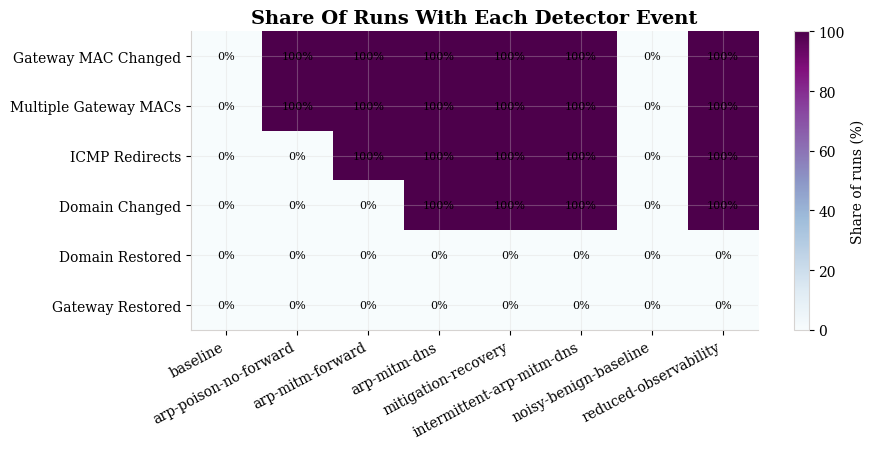

In [53]:
fields = [
    ("gateway_mac_changed", "Gateway MAC Changed"),
    ("multiple_gateway_macs_seen", "Multiple Gateway MACs"),
    ("icmp_redirects_seen", "ICMP Redirects"),
    ("domain_resolution_changed", "Domain Changed"),
    ("domain_resolution_restored", "Domain Restored"),
    ("gateway_mac_restored", "Gateway Restored"),
]
scenarios = scenario_order(rows_all)
matrix = []
for field, _label in fields:
    row_values = []
    for scenario in scenarios:
        scenario_rows = rows_for_scenario(rows_all, scenario)
        present = sum(1 for row in scenario_rows if int(row.get(field, 0) or 0) > 0)
        row_values.append(present / len(scenario_rows) * 100.0 if scenario_rows else math.nan)
    matrix.append(row_values)
fig, ax = plt.subplots(figsize=(max(7, len(scenarios) * 1.15), 4.6))
image = ax.imshow(matrix, aspect="auto", cmap="BuPu", vmin=0, vmax=100)
ax.set_xticks(range(len(scenarios)))
ax.set_xticklabels([SCENARIO_LABELS[s] for s in scenarios], rotation=28, ha="right")
ax.set_yticks(range(len(fields)))
ax.set_yticklabels([label for _, label in fields])
ax.set_title("Share Of Runs With Each Detector Event")
for r, row in enumerate(matrix):
    for c, value in enumerate(row):
        ax.text(c, r, f"{value:.0f}%", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="Share of runs (%)")
fig.tight_layout()


## Restoration ordering

    This only uses mitigation runs and compares gateway restoration versus domain restoration timing.

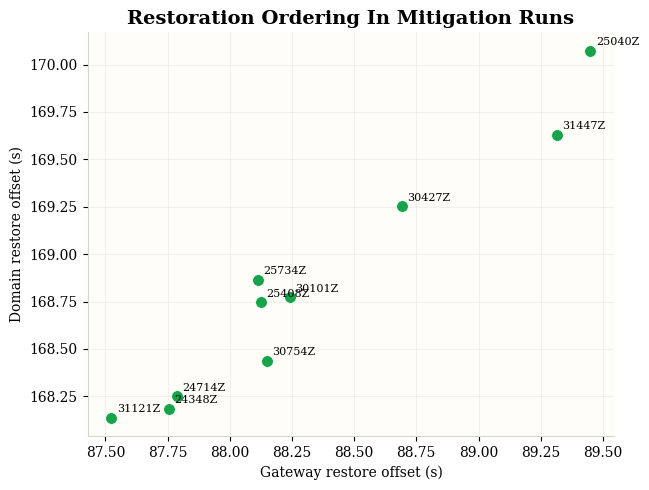

In [55]:
points = []
for row in rows_all:
    if str(row["scenario"]) != "mitigation-recovery":
        continue
    records = load_jsonl(run_dir_for_row(row) / "victim" / "detector.delta.jsonl")
    gateway_restore = None
    domain_restore = None
    for record in records:
        offset = seconds_between(row.get("started_at"), record.get("ts"))
        if offset is None:
            continue
        if record.get("event") == "gateway_mac_restored" and gateway_restore is None:
            gateway_restore = offset
        if record.get("event") == "domain_resolution_restored" and domain_restore is None:
            domain_restore = offset
    if gateway_restore is not None and domain_restore is not None:
        points.append((gateway_restore, domain_restore, str(row["run_id"])))
fig, ax = plt.subplots(figsize=(6.6, 5.0))
ax.scatter([x for x, _, _ in points], [y for _, y, _ in points], s=70, color="#16a34a", edgecolors="white", linewidths=0.45)
for x, y, run_id in points:
    ax.annotate(run_id[-6:], (x, y), textcoords="offset points", xytext=(4, 4), fontsize=8)
ax.set_xlabel("Gateway restore offset (s)")
ax.set_ylabel("Domain restore offset (s)")
ax.set_title("Restoration Ordering In Mitigation Runs")
fig.tight_layout()


## PCAP Forensics


In [56]:
GENERIC_PROTOCOLS = {"", "frame", "eth", "ethertype", "ip", "ipv6", "tcp", "udp", "data", "geninfo"}

def choose_row(rows, run_id=None):
    if run_id is not None:
        for row in rows:
            if str(row["run_id"]) == str(run_id):
                return row
        raise KeyError(f"Run id not found: {run_id}")
    row = representative_row(
        rows,
        ["mitigation-recovery", "arp-mitm-dns", "arp-mitm-forward", "arp-poison-no-forward"],
        lambda item: (run_dir_for_row(item) / "pcap" / "victim.pcap").exists(),
    )
    if row is None:
        raise ValueError("Could not choose a representative pcap run")
    return row

def pcap_path(row, capture="victim"):
    return run_dir_for_row(row) / "pcap" / f"{capture}.pcap"

def wireshark_command(row, capture="victim"):
    return f'wireshark "{pcap_path(row, capture=capture)}"'

def protocol_from_stack(stack):
    if not stack:
        return "unknown"
    candidates = [token.strip() for token in str(stack).split(":") if token.strip()]
    for candidate in reversed(candidates):
        if candidate.lower() not in GENERIC_PROTOCOLS:
            return candidate
    return candidates[-1] if candidates else "unknown"

def tshark_rows(pcap_file, fields, display_filter=None):
    if shutil.which("tshark") is None:
        raise RuntimeError("tshark is not installed on this host")
    command = ["tshark", "-r", str(pcap_file), "-T", "fields", "-E", "header=y", "-E", "separator=	", "-E", "occurrence=f", "-E", "aggregator=,"]
    if display_filter:
        command.extend(["-Y", display_filter])
    for field in fields:
        command.extend(["-e", field])
    result = subprocess.run(command, check=False, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(result.stderr.strip() or f"tshark failed for {pcap_file}")
    reader = csv.DictReader(result.stdout.splitlines(), delimiter="	")
    return [{key: (value or "").strip() for key, value in record.items()} for record in reader if record]

rows_all = load_rows("all")
RUN_ID = None
CAPTURE = "victim"
row = choose_row(rows_all, RUN_ID)
print(wireshark_command(row, capture=CAPTURE))


wireshark "/home/lutyk/Desktop/mad-mitm-in-lan/results/20260418T224348Z-mitigation-recovery/pcap/victim.pcap"


## Capture overview

    Start here before reading the detailed packet tables.

In [57]:
rows = tshark_rows(pcap_path(row, capture=CAPTURE), ["frame.time_epoch", "frame.protocols"])
protocols = {}
for record in rows:
    protocol = protocol_from_stack(record.get("frame.protocols"))
    protocols[protocol] = protocols.get(protocol, 0) + 1
first_ts = float(rows[0]["frame.time_epoch"]) if rows else None
last_ts = float(rows[-1]["frame.time_epoch"]) if rows else None
display_records([
    {"field": "pcap_path", "value": str(pcap_path(row, capture=CAPTURE))},
    {"field": "capture_role", "value": CAPTURE},
    {"field": "packet_count", "value": len(rows)},
    {"field": "duration_seconds", "value": (last_ts - first_ts) if first_ts is not None and last_ts is not None else None},
    {"field": "top_protocol", "value": max(protocols, key=protocols.get) if protocols else "n/a"},
], limit=10)


field,value
pcap_path,/home/lutyk/Desktop/mad-mitm-in-lan/results/20260418T224348Z-mitigation-recovery/pcap/victim.pcap
capture_role,victim
packet_count,20000
duration_seconds,24.14518094062805
top_protocol,iperf3


## Top conversations

    This is the compact Wireshark-style conversation summary.

In [62]:
rows = tshark_rows(pcap_path(row, capture=CAPTURE), ["ip.src", "ip.dst", "frame.protocols", "frame.len"], display_filter="ip")
totals = {}
for record in rows:
    src = record.get("ip.src") or "n/a"
    dst = record.get("ip.dst") or "n/a"
    protocol = protocol_from_stack(record.get("frame.protocols"))
    key = (src, dst, protocol)
    totals.setdefault(key, {"src": src, "dst": dst, "protocol": protocol, "packets": 0, "bytes": 0})
    totals[key]["packets"] += 1
    totals[key]["bytes"] += int(record.get("frame.len") or 0)
ranked = sorted(totals.values(), key=lambda item: (item["bytes"], item["packets"]), reverse=True)
display_records(ranked, limit=20)


src,dst,protocol,packets,bytes
10.20.20.10,10.20.20.1,iperf3,19112,28857486
10.20.20.1,10.20.20.10,tcp,542,35812
172.66.147.243,10.20.20.10,tls,18,17053
104.20.23.154,10.20.20.10,tls,18,17052
10.20.20.10,10.20.20.1,ssh,40,15837
10.20.20.1,10.20.20.10,ssh,31,15343
10.20.20.10,104.20.23.154,tls,18,3579
10.20.20.10,172.66.147.243,tls,18,3579
10.20.20.1,10.20.20.10,dns,21,2282
10.20.20.10,10.20.20.1,dns,24,2199


## ARP / DNS / ICMP evidence tables

    These are the direct packet tables you will usually want before opening Wireshark.

In [64]:
arp_rows = tshark_rows(pcap_path(row, capture=CAPTURE), ["frame.time_epoch", "eth.src", "arp.src.proto_ipv4", "arp.dst.proto_ipv4"], display_filter="arp.opcode==2")
dns_rows = tshark_rows(pcap_path(row, capture=CAPTURE), ["frame.time_epoch", "ip.src", "ip.dst", "dns.qry.name", "dns.a"], display_filter="dns.flags.response==1")
icmp_rows = tshark_rows(pcap_path(row, capture=CAPTURE), ["frame.time_epoch", "ip.src", "ip.dst", "icmp.code"], display_filter="icmp.type==5")
print("ARP replies")
display_records(arp_rows, limit=15)
print("DNS answers")
display_records(dns_rows, limit=15)
print("ICMP redirects")
display_records(icmp_rows, limit=15)


ARP replies


frame.time_epoch,eth.src,arp.src.proto_ipv4,arp.dst.proto_ipv4
1776552274.762395000,52:54:00:aa:20:66,10.20.20.66,10.20.20.10
1776552274.925617000,52:54:00:aa:20:10,10.20.20.10,10.20.20.66
1776552280.704040000,52:54:00:aa:20:10,10.20.20.10,10.20.20.66
1776552281.140880000,52:54:00:aa:20:66,10.20.20.1,10.20.20.10
1776552283.170049000,52:54:00:aa:20:66,10.20.20.1,10.20.20.10
1776552285.049102000,52:54:00:aa:20:10,10.20.20.10,10.20.20.66
1776552285.206334000,52:54:00:aa:20:66,10.20.20.1,10.20.20.10
1776552287.236134000,52:54:00:aa:20:66,10.20.20.1,10.20.20.10


DNS answers


frame.time_epoch,ip.src,ip.dst,dns.qry.name,dns.a
1776552269.718313000,10.20.20.1,10.20.20.10,example.com,172.66.147.243
1776552269.756381000,10.20.20.1,10.20.20.10,example.org,172.66.157.237
1776552269.783787000,10.20.20.1,10.20.20.10,iana.org,192.0.43.8
1776552269.830686000,10.20.20.1,10.20.20.10,example.com,
1776552271.946523000,10.20.20.1,10.20.20.10,example.com,104.20.23.154
1776552271.980188000,10.20.20.1,10.20.20.10,example.org,104.20.26.136
1776552272.011646000,10.20.20.1,10.20.20.10,iana.org,192.0.43.8
1776552274.169291000,10.20.20.1,10.20.20.10,example.com,172.66.147.243
1776552274.196638000,10.20.20.1,10.20.20.10,example.org,172.66.157.237
1776552274.224051000,10.20.20.1,10.20.20.10,iana.org,192.0.43.8


ICMP redirects


frame.time_epoch,ip.src,ip.dst,icmp.code
1776552282.948919000,10.20.20.66,10.20.20.10,1
1776552283.995612000,10.20.20.66,10.20.20.10,1
1776552285.024852000,10.20.20.66,10.20.20.10,1
1776552288.832364000,10.20.20.66,10.20.20.10,1


## Visual Atlas


In [65]:
def attack_relative_ttd(row, tool):
    ts = row.get("detector_first_alert_at_native") if tool == "detector" else row.get(f"{tool}_first_alert_at")
    return seconds_between(row.get("attack_started_at"), ts)

rows_all = load_rows("all")


## Normalized scenario metric profile

This older heatmap is handy when you want one page that shows how scenarios differ across both network impact and alert volume.


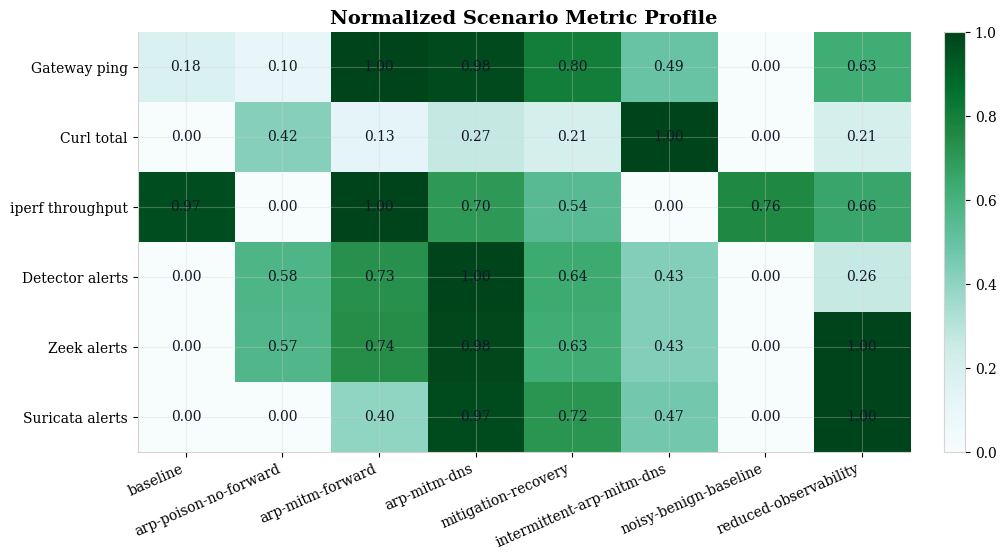

In [66]:
scenarios = scenario_order(rows_all)
metric_specs = [
    ("Gateway ping", [mean_or_none([row.get("ping_gateway_avg_ms") for row in rows_for_scenario(rows_all, scenario)]) for scenario in scenarios]),
    ("Curl total", [mean_or_none([row.get("curl_total_s") for row in rows_for_scenario(rows_all, scenario)]) for scenario in scenarios]),
    ("iperf throughput", [mean_or_none([row.get("iperf_mbps") for row in rows_for_scenario(rows_all, scenario)]) for scenario in scenarios]),
    ("Detector alerts", [mean_or_none([row.get("detector_alerts_native") for row in rows_for_scenario(rows_all, scenario)]) for scenario in scenarios]),
    ("Zeek alerts", [mean_or_none([row.get("zeek_alerts") for row in rows_for_scenario(rows_all, scenario)]) for scenario in scenarios]),
    ("Suricata alerts", [mean_or_none([row.get("suricata_alerts") for row in rows_for_scenario(rows_all, scenario)]) for scenario in scenarios]),
]
rows = []
for _, values in metric_specs:
    clean = [value for value in values if value is not None]
    low = min(clean)
    high = max(clean)
    if high == low:
        rows.append([0.5 for _ in values])
    else:
        rows.append([0.0 if value is None else (value - low) / (high - low) for value in values])
matrix = np.array(rows, dtype=float)
fig, ax = plt.subplots(figsize=(10.2, 5.7))
im = ax.imshow(matrix, cmap="BuGn", aspect="auto", vmin=0.0, vmax=1.0)
ax.set_xticks(range(len(scenarios)))
ax.set_xticklabels(scenarios, rotation=24, ha="right")
ax.set_yticks(range(len(metric_specs)))
ax.set_yticklabels([name for name, _ in metric_specs])
ax.set_title("Normalized Scenario Metric Profile")
for row_idx in range(matrix.shape[0]):
    for col_idx in range(matrix.shape[1]):
        ax.text(col_idx, row_idx, f"{matrix[row_idx, col_idx]:.2f}", ha="center", va="center", color="#111827", fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()


## Operational overhead lollipop chart

    This is a cleaner presentation view of ping versus curl overhead relative to baseline.

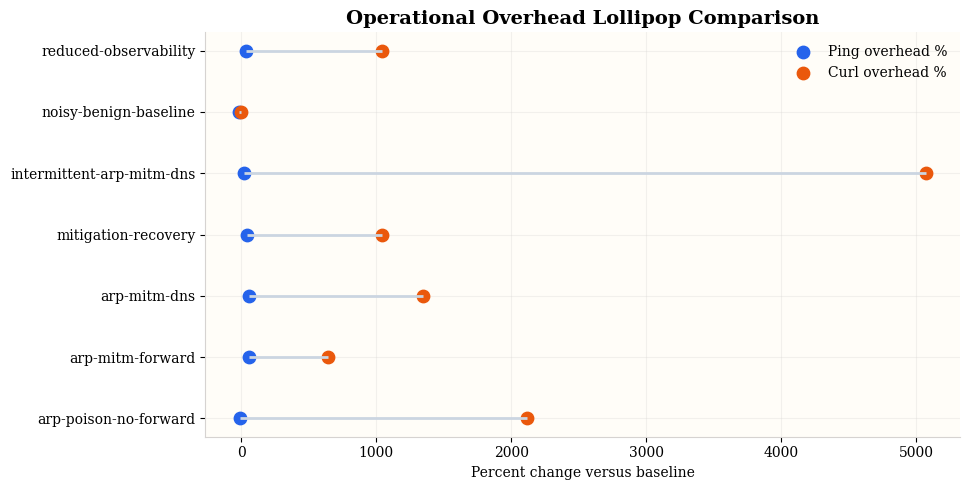

In [69]:
baseline_rows = rows_for_scenario(rows_all, "baseline")
baseline_ping = mean_or_none([row.get("ping_gateway_avg_ms") for row in baseline_rows])
baseline_curl = mean_or_none([row.get("curl_total_s") for row in baseline_rows])
scenarios = [scenario for scenario in scenario_order(rows_all) if scenario != "baseline"]
ping_over = []
curl_over = []
for scenario in scenarios:
    scenario_rows = rows_for_scenario(rows_all, scenario)
    ping = mean_or_none([row.get("ping_gateway_avg_ms") for row in scenario_rows])
    curl = mean_or_none([row.get("curl_total_s") for row in scenario_rows])
    ping_over.append(((ping - baseline_ping) / baseline_ping * 100.0) if ping is not None and baseline_ping else 0.0)
    curl_over.append(((curl - baseline_curl) / baseline_curl * 100.0) if curl is not None and baseline_curl else 0.0)
y = np.arange(len(scenarios))
fig, ax = plt.subplots(figsize=(9.8, 5.0))
for idx, (po, co) in enumerate(zip(ping_over, curl_over)):
    ax.hlines(y[idx], min(po, co), max(po, co), color="#cbd5e1", linewidth=2)
ax.scatter(ping_over, y, s=80, color="#2563eb", label="Ping overhead %")
ax.scatter(curl_over, y, s=80, color="#ea580c", label="Curl overhead %")
ax.set_yticks(y)
ax.set_yticklabels([SCENARIO_LABELS[s] for s in scenarios])
ax.set_xlabel("Percent change versus baseline")
ax.set_title("Operational Overhead Lollipop Comparison")
ax.legend()
fig.tight_layout()
